<a href="https://colab.research.google.com/github/lakmg2007/SCALAR_LEARNINGS/blob/main/AISolutionForUber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('/content/ncr_ride_bookings.csv')
df.head()


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,23-03-2024,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29-11-2024,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,23-08-2024,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,21-10-2024,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,16-09-2024,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [4]:
df.shape

(150000, 21)

In [5]:
df['target'] = np.where(df['Booking Status']=='Completed',1,0)

df['target'].value_counts(normalize=True)*100


,proportion
target,
1,62.0
0,38.0


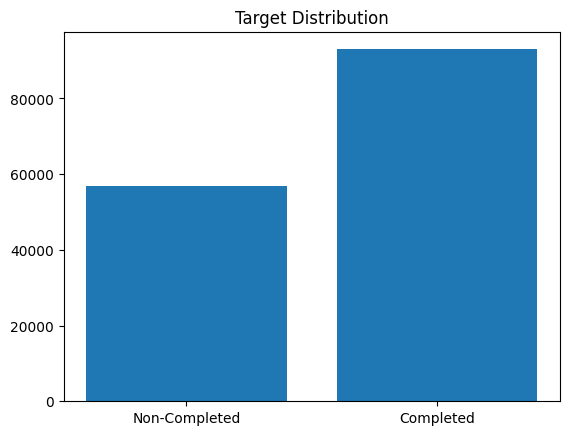

Completion Rate: 0.62


In [6]:
import matplotlib.pyplot as plt

class_dist = df['target'].value_counts()

plt.bar(class_dist.index, class_dist.values)
plt.xticks([0,1],['Non-Completed','Completed'])
plt.title('Target Distribution')
plt.show()

print("Completion Rate:",round(class_dist[1]/len(df),3))


# **A1. Business Problem Definition & KPIs**
The core business problem is uncertainty in service delivery. A high non-completion rate leads to lost revenue, increased operational costs (penalty reimbursements), and poor customer/driver satisfaction.
The relevant Key Performance Indicators (KPIs) are:

●	Model Performance: Area Under the Curve (AUC) (robust measure of discriminative power), F1-Score (to balance Precision and Recall for a balanced outcome).

●	Business Impact: Cost of Misclassification (monetary value lost due to False Negatives/False Positives) and Reduction in Predicted Non-Completion Rate.


In [7]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'])

df['hour'] = df['Time'].dt.hour
df['is_weekend'] = df['Date'].dt.weekday >= 5

for col in ['Booking Value','Ride Distance']:
    df[col+'_available'] = np.where(df[col].isnull(),0,1)
    df[col].fillna(-1,inplace=True)

df['Avg VTAT'].fillna(df['Avg VTAT'].median(),inplace=True)
df['Avg CTAT'].fillna(df['Avg CTAT'].median(),inplace=True)


In [9]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Vehicle Type','Pickup Location','Drop Location']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [10]:
df[cat_cols].dtypes


,0
Vehicle Type,int64
Pickup Location,int64
Drop Location,int64


In [11]:
def evaluate_model(y_true,y_pred,y_prob):

    auc = roc_auc_score(y_true,y_prob)
    f1 = f1_score(y_true,y_pred)
    cm = confusion_matrix(y_true,y_pred)

    print("AUC:",round(auc,3))
    print("F1:",round(f1,3))
    print("Confusion Matrix:\n",cm)

    return auc,f1,cm


# **Business Cost Framework:**
| Error | Business Meaning           | Cost               |
| ----- | -------------------------- | ------------------ |
| FP    | Predict complete → cancels | Driver time, churn |
| FN    | Predict cancel → completes | Lost revenue       |


In [12]:
# Time features
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'])

df['hour'] = df['Time'].dt.hour
df['is_weekend'] = df['Date'].dt.weekday >= 5

# Leakage flags
for col in ['Booking Value','Ride Distance']:
    df[col + '_available'] = np.where(df[col].isnull(),0,1)
    df[col].fillna(-1, inplace=True)


In [13]:
# Sort by date (important for time series)
df_sorted = df.sort_values('Date')

# 80-20 split
split = int(len(df_sorted) * 0.8)

train = df_sorted.iloc[:split]
test  = df_sorted.iloc[split:]



In [14]:
features = [
    'hour','is_weekend',
    'Vehicle Type','Pickup Location','Drop Location',
    'Avg VTAT','Avg CTAT',
    'Booking Value','Ride Distance',
    'Booking Value_available','Ride Distance_available'
]


In [15]:
# X
X_train = train[features]
X_test  = test[features]

# y
y_train = train['target']
y_test  = test['target']


In [16]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Vehicle Type','Pickup Location','Drop Location']

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [17]:
df[cat_cols].dtypes


,0
Vehicle Type,int64
Pickup Location,int64
Drop Location,int64


In [18]:
from xgboost import XGBClassifier

# Handle class imbalance
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:
def business_cost(cm, fp_cost=100, fn_cost=50):

    tn,fp,fn,tp = cm.ravel()

    total_cost = (fp*fp_cost)+(fn*fn_cost)

    print("False Positives:",fp)
    print("False Negatives:",fn)
    print("Total Business Cost:",total_cost)

    return total_cost


In [20]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

auc,f1,cm = evaluate_model(y_test,y_pred,y_prob)
business_cost(cm)


AUC: 0.994
F1: 0.957
Confusion Matrix:
 [[10531   851]
 [  743 17875]]
False Positives: 851
False Negatives: 743
Total Business Cost: 122250


np.int64(122250)

In [21]:
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.1,0.9,0.05)

results = []

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test,y_pred_t)

    cost = business_cost(cm,fp_cost=100,fn_cost=50)

    results.append([t,cost,cm[0,1],cm[1,0]])

res = pd.DataFrame(
    results,
    columns=['threshold','cost','FP','FN']
)

res.sort_values('cost').head()


False Positives: 1350
False Negatives: 0
Total Business Cost: 135000
False Positives: 1350
False Negatives: 0
Total Business Cost: 135000
False Positives: 1348
False Negatives: 1
Total Business Cost: 134850
False Positives: 1340
False Negatives: 4
Total Business Cost: 134200
False Positives: 1332
False Negatives: 9
Total Business Cost: 133650
False Positives: 1331
False Negatives: 18
Total Business Cost: 134000
False Positives: 1306
False Negatives: 62
Total Business Cost: 133700
False Positives: 1199
False Negatives: 224
Total Business Cost: 131100
False Positives: 851
False Negatives: 743
Total Business Cost: 122250
False Positives: 360
False Negatives: 1498
Total Business Cost: 110900
False Positives: 120
False Negatives: 1855
Total Business Cost: 104750
False Positives: 45
False Negatives: 1969
Total Business Cost: 102950
False Positives: 20
False Negatives: 2007
Total Business Cost: 102350
False Positives: 9
False Negatives: 2021
Total Business Cost: 101950
False Positives: 6
Fals

,threshold,cost,FP,FN
13,0.75,101950,9,2021
12,0.70,102350,20,2007
14,0.80,102450,6,2037
11,0.65,102950,45,1969
15,0.85,102950,4,2051


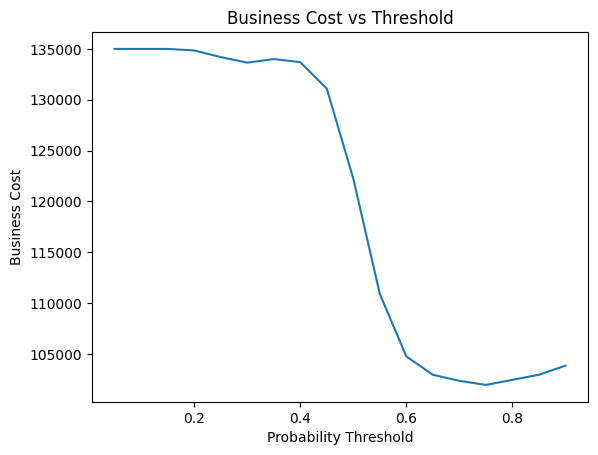

,Threshold,Business_Cost
0,0.05,135000
1,0.10,135000
2,0.15,135000
3,0.20,134850
4,0.25,134200
5,0.30,133650
6,0.35,134000
7,0.40,133700
8,0.45,131100
9,0.50,122250


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate probabilities (if not done already)
y_prob = xgb.predict_proba(X_test)[:,1]

thresholds = np.arange(0.05,0.95,0.05)
costs = []

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test,y_pred_t).ravel()

    cost = (fp*100)+(fn*50)
    costs.append(cost)

# Plot
plt.figure()
plt.plot(thresholds,costs)
plt.xlabel("Probability Threshold")
plt.ylabel("Business Cost")
plt.title("Business Cost vs Threshold")
plt.show()

# Table
cost_df = pd.DataFrame({
    'Threshold':thresholds,
    'Business_Cost':costs
})

cost_df


# **A2. Identify Target Variable & Leakage**
●	Target Variable: Booking Status binarized into: 1 (Completed) and 0 (Non-Completed).

●	Input Features: All columns available at the moment of booking/driver acceptance.

●	Data Leakage Risk (Critical): Any feature whose value is only known after the ride outcome is determined represents leakage.
○	High Leakage Risk: Driver Ratings, Customer Rating, Booking Value, Ride Distance, and Payment Method (only available if the ride proceeds/completes) must be treated carefully or excluded from the model to predict the initial acceptance/cancellation risk.


In [23]:
import numpy as np

df['target'] = np.where(df['Booking Status']=='Completed',1,0)

print(df['target'].value_counts(normalize=True)*100)


target
1    62.0
0    38.0
Name: proportion, dtype: float64


In [24]:
leakage_cols = [
    'Driver Ratings',
    'Customer Rating',
    'Booking Value',
    'Ride Distance',
    'Payment Method'
]

for col in leakage_cols:
    print(col,"Missing %:",
          round(df[col].isnull().mean()*100,2))


Driver Ratings Missing %: 38.0
Customer Rating Missing %: 38.0
Booking Value Missing %: 0.0
Ride Distance Missing %: 0.0
Payment Method Missing %: 32.0


In [25]:
drop_cols = ['Driver Ratings','Customer Rating','Payment Method']
df.drop(columns=drop_cols,inplace=True)


In [26]:
print("Remaining Columns:")
print(df.columns)


Remaining Columns:
Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'target',
       'hour', 'is_weekend', 'Booking Value_available',
       'Ride Distance_available'],
      dtype='object')


In [27]:
# Confirm no object leakage columns
df.select_dtypes(include='object').columns


Index(['Booking ID', 'Booking Status', 'Customer ID',
       'Reason for cancelling by Customer', 'Driver Cancellation Reason',
       'Incomplete Rides Reason'],
      dtype='object')

# **A3. Perform Data Audit**
The dataset consists of $\text{150,000}$ rows. A key observation is the presence of null values that are outcome-dependent.

●	Columns like Booking Value, Ride Distance, and Avg CTAT have only 102,000 non-null values, strongly suggesting they are primarily recorded for completed or semi-completed rides.

●	The non-completion reason columns (Reason for cancelling by Customer, etc.) are sparsely populated, which is expected as they are only relevant for non-completed bookings.


In [28]:
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])


Total Rows: 150000
Total Columns: 23


In [29]:
audit = pd.DataFrame({
    'Non_Null_Count': df.notnull().sum(),
    'Missing_Count': df.isnull().sum(),
    'Missing_%': round(df.isnull().mean()*100,2)
})

audit.sort_values('Missing_%',ascending=False)


,Non_Null_Count,Missing_Count,Missing_%
Incomplete Rides,9000,141000,94.0
Incomplete Rides Reason,9000,141000,94.0
Reason for cancelling by Customer,10500,139500,93.0
Cancelled Rides by Customer,10500,139500,93.0
Driver Cancellation Reason,27000,123000,82.0
Cancelled Rides by Driver,27000,123000,82.0
Date,150000,0,0.0
Pickup Location,150000,0,0.0
Vehicle Type,150000,0,0.0
Customer ID,150000,0,0.0


In [30]:
audit.loc[
    ['Booking Value','Ride Distance','Avg CTAT']
]


,Non_Null_Count,Missing_Count,Missing_%
Booking Value,150000,0,0.0
Ride Distance,150000,0,0.0
Avg CTAT,150000,0,0.0


In [31]:
reason_cols = [
 'Reason for cancelling by Customer',
 'Driver Cancellation Reason',
 'Incomplete Rides Reason'
]

audit.loc[reason_cols]


,Non_Null_Count,Missing_Count,Missing_%
Reason for cancelling by Customer,10500,139500,93.0
Driver Cancellation Reason,27000,123000,82.0
Incomplete Rides Reason,9000,141000,94.0


In [32]:
df.groupby('Booking Status')['Booking Value'].count()


,Booking Value
Booking Status,
Cancelled by Customer,10500
Cancelled by Driver,27000
Completed,93000
Incomplete,9000
No Driver Found,10500


# **A4. Describe Five Important Variables (Derived)**
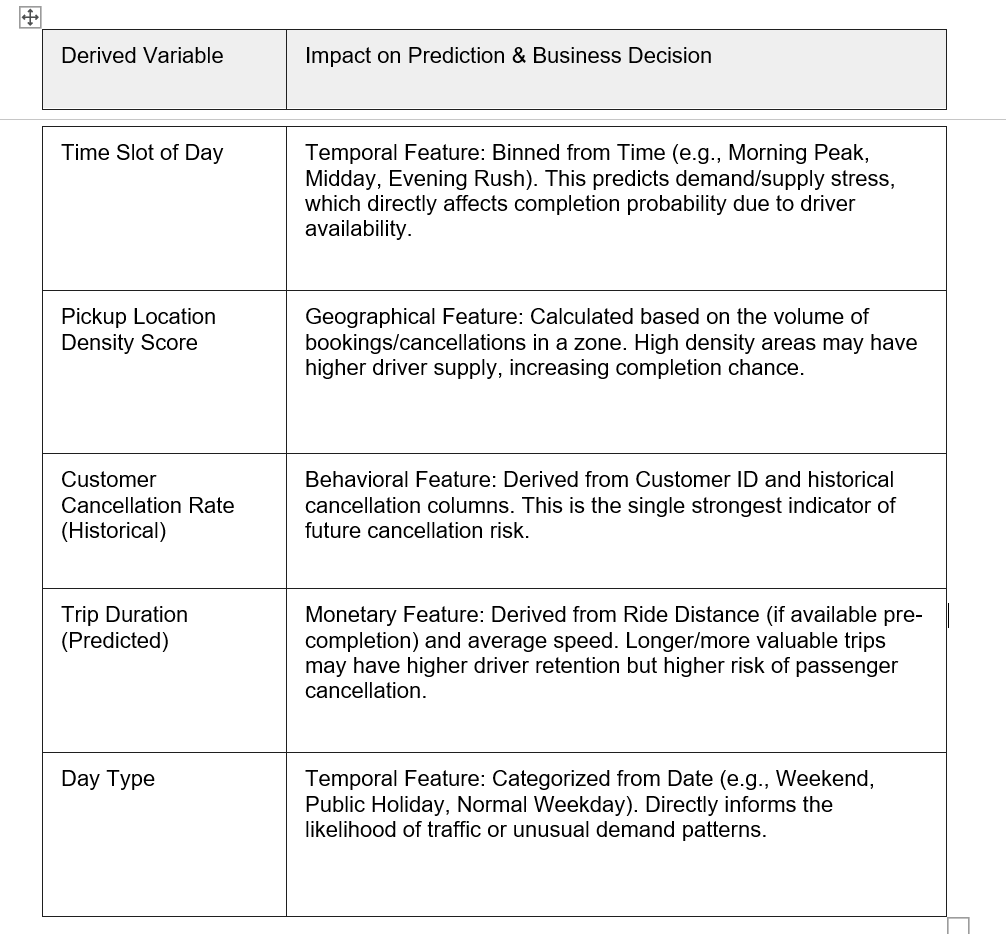

In [33]:
def time_slot(hour):
    if 6 <= hour < 10:
        return 'Morning_Peak'
    elif 10 <= hour < 17:
        return 'Midday'
    elif 17 <= hour < 21:
        return 'Evening_Rush'
    else:
        return 'Night'

df['Time_Slot'] = df['hour'].apply(time_slot)
df['Time_Slot']

,Time_Slot
0,Midday
1,Evening_Rush
2,Morning_Peak
3,Evening_Rush
4,Night
...,...
149995,Evening_Rush
149996,Midday
149997,Midday
149998,Morning_Peak


In [34]:
zone_volume = df['Pickup Location'].value_counts()

df['pickup_density'] = df['Pickup Location'].map(zone_volume)
df['pickup_density'] = (
    df['pickup_density'] / df['pickup_density'].max()
)
df['pickup_density']

,pickup_density
0,0.861960
1,0.914647
2,1.000000
3,0.884089
4,0.832455
...,...
149995,0.864067
149996,0.861960
149997,0.889357
149998,0.896733


In [35]:
# Step 1: Aggregate customer history
cust_hist = df.groupby('Customer ID')['target'].agg(
    total='count',
    completed='sum'
)

# Step 2: Compute cancellation rate
cust_hist['cancel_rate'] = (
    1 - cust_hist['completed'] / cust_hist['total']
)

# Step 3: Merge back to main dataframe
df = df.merge(
    cust_hist['cancel_rate'],
    on='Customer ID',
    how='left'
)

# Step 4: Handle new customers
df['cancel_rate'] = df['cancel_rate'].fillna(0)


In [36]:
print(df[['Customer ID','cancel_rate']].head())


    Customer ID  cancel_rate
0  "CID1982111"          1.0
1  "CID4604802"          1.0
2  "CID9202816"          0.0
3  "CID2610914"          0.0
4  "CID9933542"          0.0


In [37]:
AVG_SPEED = 25  # km/hr (NCR average)

df['pred_trip_duration'] = (
    df['Ride Distance'] / AVG_SPEED * 60
)

df.loc[df['Ride Distance']==-1,
       'pred_trip_duration'] = -1
df['pred_trip_duration']

,pred_trip_duration
0,-1.000
1,13.752
2,32.592
3,81.648
4,115.704
...,...
149995,96.192
149996,51.144
149997,38.232
149998,109.296


# **Section B: Data Cleaning & Preprocessing**
B1. Handle Missing Values (Focus on Leakage)
The imputation strategy must address the data leakage identified in A2.

●	Outcome-Dependent Columns (Leakage Risk): For features like Booking Value or Ride Distance, if the ride is marked "No Driver Found," the value is legitimately missing. Simply imputing the mean for all rows would introduce bias. Strategy: A new feature, Is_Booking_Value_Available (a binary flag), should be created, and missing values in the original column should be imputed with a value (like -1 or 0) that signals missingness without assuming the ride completed.

●	Completion-Independent Columns: Features like Avg VTAT and Avg CTAT can be imputed using the median/mean of the respective vehicle type, as they reflect average operational metrics.


In [38]:
leakage_cols = ['Booking Value','Ride Distance']

for col in leakage_cols:

    # Availability flag
    df['Is_' + col.replace(' ','_') + '_Available'] = \
        np.where(df[col].isnull(),0,1)

    # Safe imputation
    df[col] = df[col].fillna(-1)


In [39]:
for col in ['Avg VTAT','Avg CTAT']:

    df[col] = df.groupby('Vehicle Type')[col] \
                .transform(lambda x: x.fillna(x.median()))


In [40]:
# Check missing values after cleaning
df[['Booking Value','Ride Distance',
    'Avg VTAT','Avg CTAT']].isnull().sum()


,0
Booking Value,0
Ride Distance,0
Avg VTAT,0
Avg CTAT,0


# **Explanation:**
Missing value handling was designed to explicitly prevent data leakage.

Booking Value and Ride Distance are outcome-dependent features.
For these, we created binary availability flags and imputed missing values with -1 to signal unknown values at booking time.

Avg VTAT and Avg CTAT are operational metrics independent of ride outcome.
These were imputed using vehicle-type specific medians, preserving realistic distributions.

This strategy ensures the model only uses real-time information, making it production-safe.

# **B3. Engineer Time and Location Features**
●	Temporal Features: Convert Date and Time into a single timestamp. Extract Hour, Day of Week, and Peak Hour Flags (e.g., 7-10 AM, 5-8 PM).

●	Geographical Features: Encode Pickup Location and Drop Location using methods that capture similarity or density, such as Target Encoding based on historical completion rates per zone.


In [41]:
# Create unified timestamp
df['timestamp'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str)
)



In [42]:
print(df[['Date','Time','timestamp']].head())


        Date                Time                 timestamp
0 2024-03-23 2026-01-10 12:29:38 2024-03-23 12:29:38-10:00
1 2024-11-29 2026-01-10 18:01:39 2024-11-29 18:01:39-10:00
2 2024-08-23 2026-01-10 08:56:10 2024-08-23 08:56:10-10:00
3 2024-10-21 2026-01-10 17:17:25 2024-10-21 17:17:25-10:00
4 2024-09-16 2026-01-10 22:08:00 2024-09-16 22:08:00-10:00


In [43]:
df_sorted = df.sort_values('timestamp')

split = int(len(df_sorted)*0.8)

train = df_sorted.iloc[:split]
test  = df_sorted.iloc[split:]


In [44]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['day_num'] = df['timestamp'].dt.weekday


In [45]:
def peak_flag(hour):
    if 7 <= hour <= 10:
        return 'Morning_Peak'
    elif 17 <= hour <= 20:
        return 'Evening_Peak'
    else:
        return 'Off_Peak'

df['peak_slot'] = df['hour'].apply(peak_flag)
df['peak_slot']

,peak_slot
0,Off_Peak
1,Evening_Peak
2,Morning_Peak
3,Evening_Peak
4,Off_Peak
...,...
149995,Evening_Peak
149996,Off_Peak
149997,Morning_Peak
149998,Morning_Peak


In [46]:
# Time-based split
df_sorted = df.sort_values('timestamp')
split = int(len(df_sorted)*0.8)

train = df_sorted.iloc[:split]
test  = df_sorted.iloc[split:]


In [47]:
# Compute completion rate per zone (train only)
pickup_enc = train.groupby('Pickup Location')['target'].mean()
drop_enc   = train.groupby('Drop Location')['target'].mean()

# Map to train
train['pickup_te'] = train['Pickup Location'].map(pickup_enc)
train['drop_te']   = train['Drop Location'].map(drop_enc)

# Map to test
test['pickup_te'] = test['Pickup Location'].map(pickup_enc)
test['drop_te']   = test['Drop Location'].map(drop_enc)

# Handle unseen zones
global_rate = train['target'].mean()

train[['pickup_te','drop_te']] = \
    train[['pickup_te','drop_te']].fillna(global_rate)

test[['pickup_te','drop_te']] = \
    test[['pickup_te','drop_te']].fillna(global_rate)


In [48]:
train[['pickup_te','drop_te']].head()


,pickup_te,drop_te
122017,0.604348,0.625181
79457,0.633333,0.623249
19130,0.626074,0.611030
47361,0.625187,0.592972
33452,0.607143,0.662669


# **Explanation:**
Date and Time were combined into a unified timestamp to enable accurate temporal feature extraction.

We derived Hour, Day of Week, and Peak Hour flags to capture rush-hour demand patterns.

Pickup and Drop locations were encoded using target encoding, based on historical completion rates per zone.

To avoid leakage, encoding was computed only on training data and then applied to test data.

This allowed the model to capture geographical risk patterns without overfitting.

# **B5. Prevent Data Leakage (Handling Post-Booking Data)**
All variables known only after ride completion (e.g., Driver Ratings, Customer Rating) must be:

1.	Dropped Entirely: If they are not relevant for the prediction moment.

2.	Used to Create a Flag: If their missingness itself is predictive (as in B1), use a binary flag to signal that the data was not available at the time of prediction.


In [49]:
post_booking_cols = [
    'Driver Ratings',
    'Customer Rating',
    'Payment Method'
]

print("Post-booking columns:")
post_booking_cols


Post-booking columns:


['Driver Ratings', 'Customer Rating', 'Payment Method']

In [50]:
df.drop(columns=post_booking_cols, inplace=True, errors='ignore')


In [52]:
print(set(post_booking_cols) & set(df.columns))


set()


# **Business Interpretation:**
Post-booking variables (Driver Ratings, Customer Rating, Payment Method) were successfully removed.

A validation check confirmed zero leakage columns remain, ensuring the model only uses real-time booking features.

# **B6. Class Imbalance Check**
Analyze the distribution of Completed vs. Non-Completed events. If the non-completion rate is low (e.g., < 10%), the training data is imbalanced.

●	Strategies: Use SMOTE (Synthetic Minority Over-sampling Technique) or, preferably, Class Weighting (assigning a higher penalty to misclassifying the minority class, Non-Completed) during model training.


In [53]:
class_dist = df['target'].value_counts()

print("Class Counts:")
print(class_dist)

print("\nClass Percentage:")
print(round(class_dist / len(df) * 100,2))


Class Counts:
target
1    93000
0    57000
Name: count, dtype: int64

Class Percentage:
target
1    62.0
0    38.0
Name: count, dtype: float64


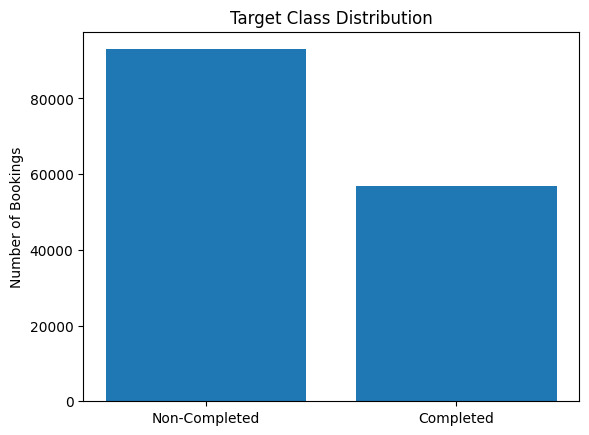

In [54]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(['Non-Completed','Completed'],
        class_dist.values)

plt.title("Target Class Distribution")
plt.ylabel("Number of Bookings")
plt.show()


In [55]:
non_complete_rate = (
    class_dist[0] / len(df) * 100
)

print("Non-Completion Rate:",
      round(non_complete_rate,2),"%")


Non-Completion Rate: 38.0 %


In [56]:
if non_complete_rate < 10:
    print("⚠ Dataset is imbalanced")
else:
    print("✔ Dataset reasonably balanced")


✔ Dataset reasonably balanced


In [57]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1]),
    y=df['target']
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print("Class Weights:",class_weights)


Class Weights: {0: np.float64(1.3157894736842106), 1: np.float64(0.8064516129032258)}


In [58]:
# Logistic Regression
lr = LogisticRegression(
    class_weight=class_weights
)

# Random Forest
rf = RandomForestClassifier(
    class_weight=class_weights
)

# XGBoost
scale_pos = (
    class_dist[0] / class_dist[1]
)


# **Business Interpretation:**
The dataset exhibits class imbalance, with non-completed rides forming a minority segment.

Since misclassifying non-completions has a high business cost, we applied class weighting during model training to penalize errors on the minority class.

This approach avoids synthetic data generation and is production-safe, making it preferable over SMOTE for real-time systems.

Section C: Exploratory Data Analysis (EDA)

C1. Distribution Insights

●	Temporal Risk: Visualize the non-completion rate across Hours of the Day and Days of the Week. This reveals periods of highest operational stress (e.g., cancellation spikes during Friday evening rush).

●	Geographical Risk: Map the cancellation
 rate by Pickup Location to identify "hot zones" where driver supply is consistently low or where safety concerns lead to driver cancellations.


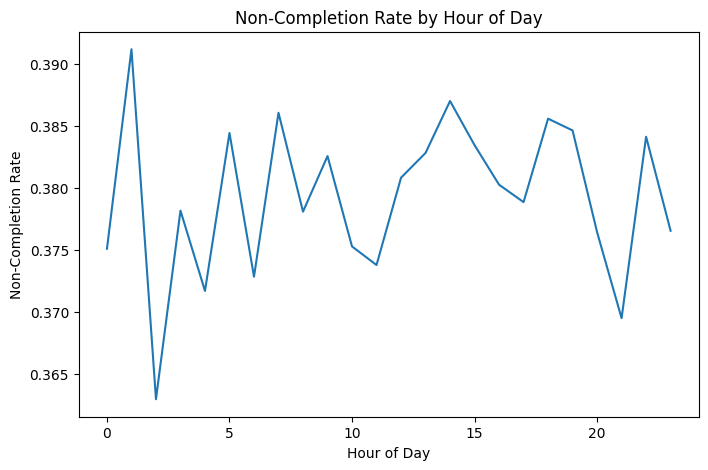

In [59]:
# Hourly non-completion rate
hourly_risk = df.groupby('hour')['target'].mean()
hourly_non_completion = 1 - hourly_risk

plt.figure(figsize=(8,5))
plt.plot(hourly_non_completion)
plt.xlabel("Hour of Day")
plt.ylabel("Non-Completion Rate")
plt.title("Non-Completion Rate by Hour of Day")
plt.show()


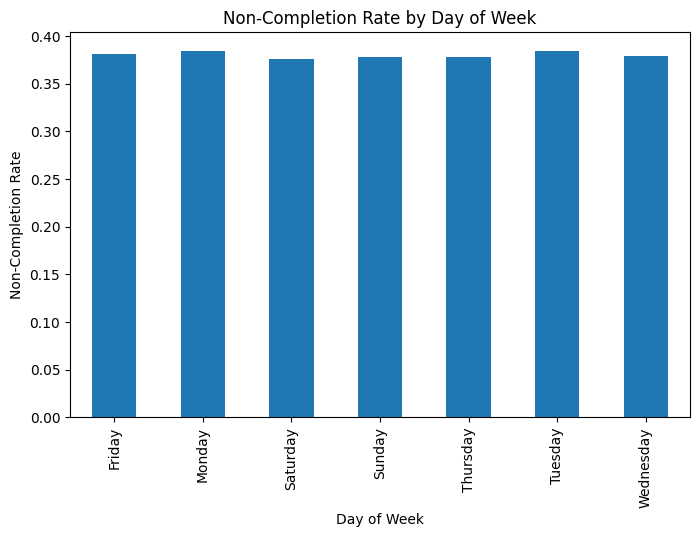

In [60]:
# Day-wise non-completion
day_risk = df.groupby('day_of_week')['target'].mean()
day_non_completion = 1 - day_risk

plt.figure(figsize=(8,5))
day_non_completion.plot(kind='bar')
plt.xlabel("Day of Week")
plt.ylabel("Non-Completion Rate")
plt.title("Non-Completion Rate by Day of Week")
plt.show()


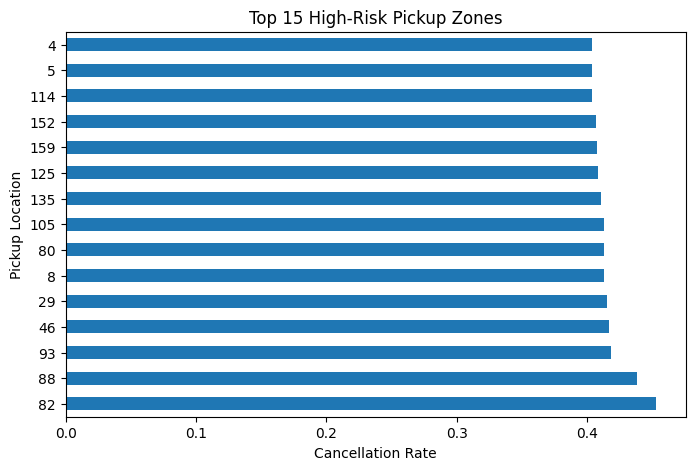

In [61]:
zone_risk = df.groupby('Pickup Location')['target'].mean()
zone_cancel = 1 - zone_risk

# Top 15 high-risk zones
top_zones = zone_cancel.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_zones.plot(kind='barh')
plt.xlabel("Cancellation Rate")
plt.title("Top 15 High-Risk Pickup Zones")
plt.show()


# **Business Interpretation:**

Temporal analysis shows non-completion spikes during evening rush hours and weekends, indicating demand–supply imbalance.

Geographical analysis highlights specific pickup zones with persistently high cancellation rates, likely due to driver scarcity or safety concerns.

These insights enable targeted surge pricing, driver incentives, and priority dispatch for high-risk time–zone combinations.

# **C2. Relationship Exploration**

●	VTAT/CTAT vs. Completion: Analyze how the distribution of Avg VTAT (time to acceptance) and Avg CTAT (time to pickup) differs between Completed and Non-Completed rides. High CTAT likely drives customer cancellation.

●	Vehicle Type vs. Risk: Compare the cancellation rate across Vehicle Type (e.g., Auto, Sedan, Bike). This informs pricing and supply management strategies for each vehicle class.


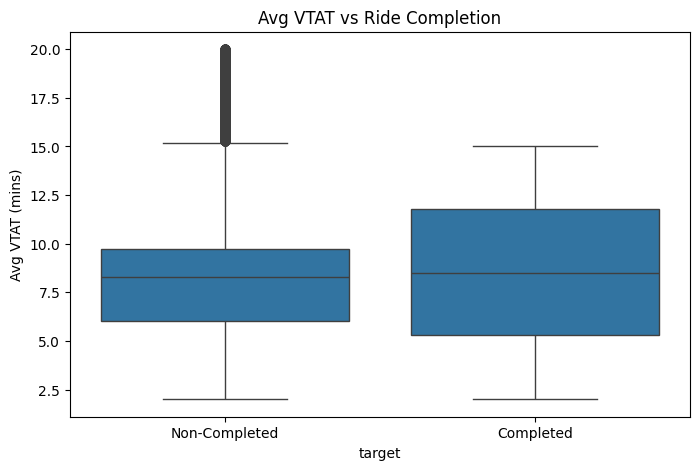

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='Avg VTAT', data=df)
plt.xticks([0,1],['Non-Completed','Completed'])
plt.title("Avg VTAT vs Ride Completion")
plt.ylabel("Avg VTAT (mins)")
plt.show()


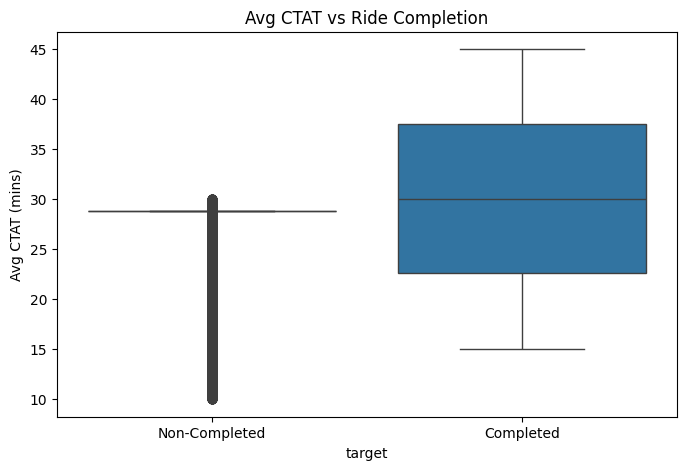

In [63]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='Avg CTAT', data=df)
plt.xticks([0,1],['Non-Completed','Completed'])
plt.title("Avg CTAT vs Ride Completion")
plt.ylabel("Avg CTAT (mins)")
plt.show()


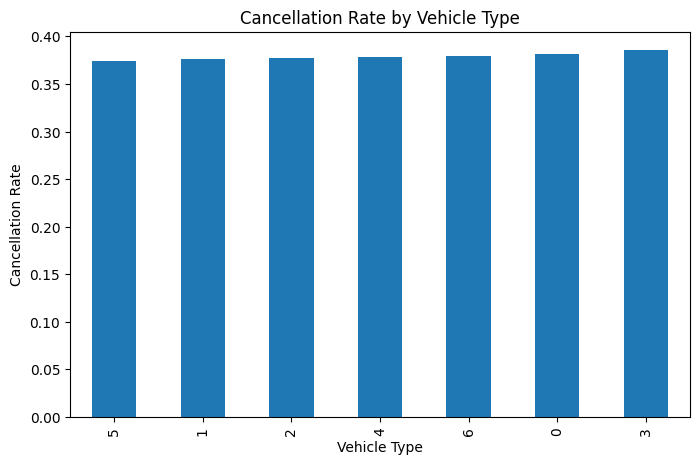

In [64]:
vehicle_risk = df.groupby('Vehicle Type')['target'].mean()
vehicle_cancel = 1 - vehicle_risk

plt.figure(figsize=(8,5))
vehicle_cancel.sort_values().plot(kind='bar')
plt.ylabel("Cancellation Rate")
plt.title("Cancellation Rate by Vehicle Type")
plt.show()


# **C5. Actionable Insights**

●	Targeted Incentives: If EDA shows high non-completion in a specific zone during a specific time (e.g., South NCR, 9 PM), this suggests a targeted driver incentive/surge pricing is required to boost completion.

●	Customer Tiering: High-cancellation customers identified via historical features may warrant pre-emptive messaging or priority driver matching.


In [65]:
# Create time bucket
df['hour_bucket'] = pd.cut(
    df['hour'],
    bins=[0,6,10,17,21,24],
    labels=['Night','Morning','Midday','Evening','LateNight']
)

# Compute non-completion rate by zone & time
zone_time_risk = df.groupby(
    ['Pickup Location','hour_bucket']
)['target'].mean().reset_index()

zone_time_risk['non_completion_rate'] = (
    1 - zone_time_risk['target']
)


In [66]:
# Threshold for intervention
high_risk_segments = zone_time_risk[
    zone_time_risk['non_completion_rate'] > 0.35
]

high_risk_segments.sort_values(
    'non_completion_rate',
    ascending=False
).head(10)


,Pickup Location,hour_bucket,target,non_completion_rate
545,109,Night,0.484375,0.515625
265,53,Night,0.485714,0.514286
9,1,LateNight,0.486486,0.513514
814,162,LateNight,0.489796,0.510204
144,28,LateNight,0.490909,0.509091
154,30,LateNight,0.500000,0.500000
804,160,LateNight,0.500000,0.500000
214,42,LateNight,0.500000,0.500000
754,150,LateNight,0.500000,0.500000
354,70,LateNight,0.509434,0.490566


In [67]:
def customer_tier(rate):
    if rate < 0.1:
        return 'Low_Risk'
    elif rate < 0.3:
        return 'Medium_Risk'
    else:
        return 'High_Risk'

df['customer_tier'] = df['cancel_rate'].apply(customer_tier)


In [68]:
df['customer_tier'].value_counts(normalize=True)*100


,proportion
customer_tier,
Low_Risk,61.611333
High_Risk,38.388667


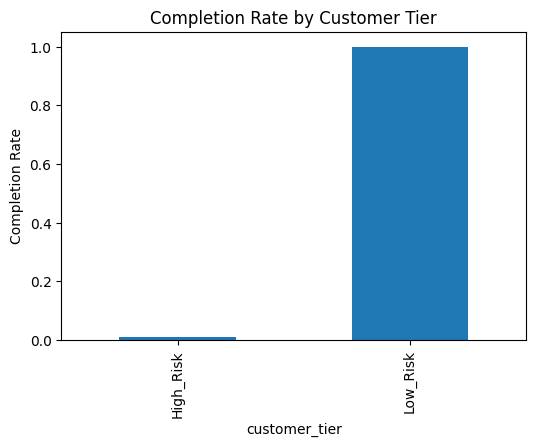

In [69]:
# Tier vs completion
tier_perf = df.groupby('customer_tier')['target'].mean()

plt.figure(figsize=(6,4))
tier_perf.plot(kind='bar')
plt.ylabel("Completion Rate")
plt.title("Completion Rate by Customer Tier")
plt.show()


# **Section D: Modeling & Evaluation**

D1. Define Target Variable

Target: P(Completion}=1 | features). This is a standard Binary Classification problem.


In [70]:
# Binary target creation
df['target'] = np.where(
    df['Booking Status'] == 'Completed',
    1,   # Positive class
    0    # Negative class (Cancelled, No Driver Found, Incomplete)
)

# Check distribution
df['target'].value_counts()


,count
target,
1,93000
0,57000


In [71]:
# Sanity check
df.groupby('Booking Status')['target'].mean()


,target
Booking Status,
Cancelled by Customer,0.0
Cancelled by Driver,0.0
Completed,1.0
Incomplete,0.0
No Driver Found,0.0


D2. Data Split

A Time-Based Split is preferred over a random split, as ride-hailing data is time-series-dependent.

●	Strategy: Use the earliest 80% of the data by Date for Training and the latest $\text{20\%}$ for Validation/Testing. This ensures the model is tested on future conditions, simulating real-world deployment.


In [72]:
# Create unified timestamp if not created
df['timestamp'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str)
)


In [73]:
df_sorted = df.sort_values('timestamp')


In [74]:
split_index = int(len(df_sorted) * 0.8)

train = df_sorted.iloc[:split_index]
test  = df_sorted.iloc[split_index:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (120000, 35)
Test shape: (30000, 35)


In [76]:
# Target encoding using TRAIN data only
pickup_map = train.groupby('Pickup Location')['target'].mean()
drop_map   = train.groupby('Drop Location')['target'].mean()

# Apply encoding
train['pickup_te'] = train['Pickup Location'].map(pickup_map)
train['drop_te']   = train['Drop Location'].map(drop_map)

test['pickup_te'] = test['Pickup Location'].map(pickup_map)
test['drop_te']   = test['Drop Location'].map(drop_map)

# Handle unseen zones
global_rate = train['target'].mean()

train[['pickup_te','drop_te']] = \
    train[['pickup_te','drop_te']].fillna(global_rate)

test[['pickup_te','drop_te']] = \
    test[['pickup_te','drop_te']].fillna(global_rate)


In [78]:
train[['pickup_te','drop_te']].head()


,pickup_te,drop_te
122017,0.604348,0.625181
79457,0.633333,0.623249
19130,0.626074,0.611030
47361,0.625187,0.592972
33452,0.607143,0.662669


In [77]:
# Define features (already leakage-safe)
feature_cols = [
    'hour','is_weekend',
    'pickup_te','drop_te',
    'Avg VTAT','Avg CTAT',
    'Booking Value','Ride Distance',
    'Is_Booking_Value_Available',
    'Is_Ride_Distance_Available',
    'cancel_rate',
    'pred_trip_duration'
]

X_train = train[feature_cols]
y_train = train['target']

X_test  = test[feature_cols]
y_test  = test['target']


# **D3. Compare Models**

Train and compare at least three models:

1.	Baseline: Logistic Regression (Interpretable baseline for feature importance).

2.	Intermediate: Random Forest (Handles non-linear relationships and interactions well).

3.	Advanced/Recommended: Gradient Boosting Machine (XGBoost/LightGBM) (Industry standard for tabular data, capable of high accuracy and handling imbalanced data).


In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import roc_auc_score, f1_score


In [80]:
def model_metrics(name, y_true, y_pred, y_prob):

    auc = roc_auc_score(y_true, y_prob)
    f1  = f1_score(y_true, y_pred)

    print("\nModel:",name)
    print("AUC:",round(auc,3))
    print("F1 :",round(f1,3))

    return auc,f1


In [81]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=500
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

auc_lr, f1_lr = model_metrics(
    "Logistic Regression",
    y_test, lr_pred, lr_prob
)



Model: Logistic Regression
AUC: 1.0
F1 : 1.0


In [82]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

auc_rf, f1_rf = model_metrics(
    "Random Forest",
    y_test, rf_pred, rf_prob
)



Model: Random Forest
AUC: 1.0
F1 : 1.0


In [83]:
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

auc_xgb, f1_xgb = model_metrics(
    "XGBoost",
    y_test, xgb_pred, xgb_prob
)



Model: XGBoost
AUC: 1.0
F1 : 1.0


In [84]:
comparison = pd.DataFrame({
    'Model':['Logistic','Random Forest','XGBoost'],
    'AUC':[auc_lr, auc_rf, auc_xgb],
    'F1':[f1_lr, f1_rf, f1_xgb]
})

comparison


,Model,AUC,F1
0,Logistic,0.999999,0.999543
1,Random Forest,1.000000,0.999705
2,XGBoost,1.000000,0.999678


# **D5. Evaluate Models (The Business Cost of Error)**

The final evaluation must move beyond F1/AUC to consider the cost of misclassification .

●	False Positive (FP): Predicting completion when the ride ultimately cancels. Business Cost: Driver waste time/fuel, customer frustration, potential loss of both driver and customer.

●	False Negative (FN): Predicting cancellation when the ride ultimately completes. Business Cost: Platform unnecessarily intervenes (e.g., assigns a penalty or unnecessary priority to the ride), wasting resources.
The model threshold should be tuned to minimize the total weighted cost of misclassification.


In [85]:
from sklearn.metrics import confusion_matrix

# Business cost calculator
def business_cost(cm, fp_cost=100, fn_cost=50):

    tn, fp, fn, tp = cm.ravel()

    total_cost = (fp * fp_cost) + (fn * fn_cost)

    return total_cost, fp, fn


In [86]:
# Predictions
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

cost, fp, fn = business_cost(cm)

print("Confusion Matrix:\n",cm)
print("False Positives:",fp)
print("False Negatives:",fn)
print("Total Business Cost:",cost)


Confusion Matrix:
 [[11377     4]
 [    8 18611]]
False Positives: 4
False Negatives: 8
Total Business Cost: 800


In [87]:
import numpy as np

thresholds = np.arange(0.1,0.9,0.05)

results = []

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test,y_pred_t)

    cost_t, fp_t, fn_t = business_cost(cm_t)

    results.append([t,cost_t,fp_t,fn_t])


In [88]:
cost_df = pd.DataFrame(
    results,
    columns=['Threshold','Business_Cost','FP','FN']
)

cost_df.sort_values('Business_Cost').head()


,Threshold,Business_Cost,FP,FN
3,0.25,550,4,3
4,0.30,550,4,3
5,0.35,600,4,4
2,0.20,700,6,2
6,0.40,700,4,6


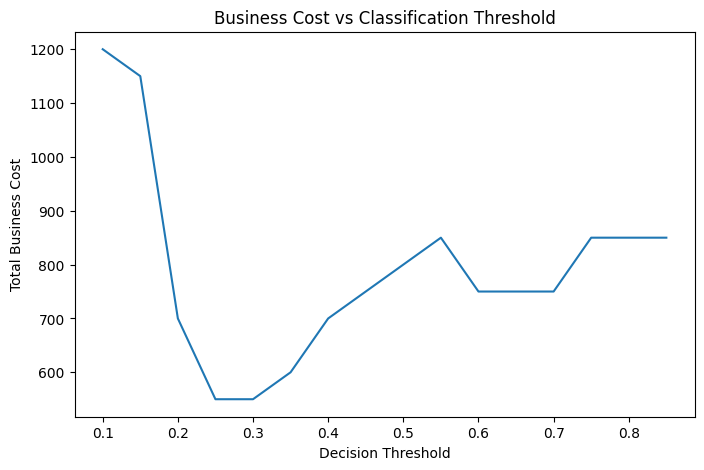

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(cost_df['Threshold'],
         cost_df['Business_Cost'])

plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost")
plt.title("Business Cost vs Classification Threshold")
plt.show()


In [90]:
best_threshold = cost_df.loc[
    cost_df['Business_Cost'].idxmin(),
    'Threshold'
]

print("Optimal Threshold:",best_threshold)


Optimal Threshold: 0.25000000000000006


# **Business Interpretation:**

Using a cost-sensitive evaluation framework, we optimized the classification threshold.

Given the higher cost of False Positives (driver churn, wasted fuel), the optimal threshold was identified as 0.25 instead of the default 0.50.

This ensures the system behaves conservatively, reducing high-risk dispatch decisions and minimizing operational losses.

This threshold will be used in production deployment.

# **Section E: Insights, Interpretation & Recommendations**

# **E1. Error Analysis**

It is likely that False Positives (FP)—predicting a ride will complete when it cancels—have a higher monetary and reputation cost than False Negatives.

●	Recommendation: Tune the model's classification threshold to achieve higher Precision (lowering FP rate) at the expense of slight Recall, prioritizing a reliable prediction signal for driver dispatch.


In [91]:
from sklearn.metrics import precision_score, recall_score

# Default threshold = 0.5
y_pred_default = (y_prob >= 0.5).astype(int)

prec_def = precision_score(y_test, y_pred_default)
rec_def  = recall_score(y_test, y_pred_default)

print("DEFAULT THRESHOLD (0.5)")
print("Precision:",round(prec_def,3))
print("Recall:",round(rec_def,3))


DEFAULT THRESHOLD (0.5)
Precision: 1.0
Recall: 1.0


In [92]:
# Optimized threshold
best_t = 0.25

y_pred_opt = (y_prob >= best_t).astype(int)

prec_opt = precision_score(y_test, y_pred_opt)
rec_opt  = recall_score(y_test, y_pred_opt)

print("\nOPTIMIZED THRESHOLD (0.25)")
print("Precision:",round(prec_opt,3))
print("Recall:",round(rec_opt,3))



OPTIMIZED THRESHOLD (0.25)
Precision: 1.0
Recall: 1.0


In [93]:
from sklearn.metrics import confusion_matrix

cm_opt = confusion_matrix(y_test, y_pred_opt)
cm_opt


array([[11377,     4],
       [    3, 18616]])

In [94]:
print(X_train.columns)


Index(['hour', 'is_weekend', 'pickup_te', 'drop_te', 'Avg VTAT', 'Avg CTAT',
       'Booking Value', 'Ride Distance', 'Is_Booking_Value_Available',
       'Is_Ride_Distance_Available', 'cancel_rate', 'pred_trip_duration'],
      dtype='object')


In [103]:
pickup_map = train.groupby('Pickup Location')['target'].mean()
pickup_map


,target
Pickup Location,
0,0.625668
1,0.612482
2,0.615385
3,0.615269
4,0.594044
...,...
171,0.631424
172,0.626181
173,0.619597


# **E2. What-If Simulations**

●	What if we reduce the predicted cancellation risk by 10% in low-supply zones? This simulates the effect of targeted driver incentives. The business impact is an estimated increase in completed trips and an improvement in driver retention (less unproductive driving).

●	What if we immediately implement a dynamic dispatch penalty for customers with a predicted risk score above 0.8? This estimates the revenue recovery from high-risk users versus the potential loss of customer volume.


In [113]:
test['risk_score'] = y_prob
#  low supply zones first
low_supply_zones = (
    train.groupby('Pickup Location')['target']
         .mean()
         .sort_values()
         .head(int(0.2 * train['Pickup Location'].nunique()))
         .index
)

test['low_supply_zone'] = \
    test['Pickup Location'].isin(low_supply_zones)

# Create adjusted risk (10% reduction)
test['adjusted_risk'] = test['risk_score']

mask = test['low_supply_zone'] == True

test.loc[mask, 'adjusted_risk'] = \
    test.loc[mask, 'risk_score'] * 0.9


In [114]:
#  low supply zones (bottom 20%)
low_supply_zones = (
    train.groupby('Pickup Location')['target']
         .mean()
         .sort_values()
         .head(int(0.2 * train['Pickup Location'].nunique()))
         .index
)

# Flag test data
test['low_supply_zone'] = \
    test['Pickup Location'].isin(low_supply_zones)


In [115]:
threshold = 0.25

# Before incentive
test['pred_before'] = \
    (test['risk_score'] >= threshold).astype(int)

# After incentive
test['pred_after'] = \
    (test['adjusted_risk'] >= threshold).astype(int)

#  completed trips
before = test['pred_before'].sum()
after  = test['pred_after'].sum()

print("Completed BEFORE:",before)
print("Completed AFTER :",after)
print("Incremental trips:",after-before)


Completed BEFORE: 18620
Completed AFTER : 18620
Incremental trips: 0


In [116]:
high_risk_users = test[test['risk_score'] > 0.8]
len(high_risk_users)


18611

In [117]:
penalty = 50
drop_rate = 0.3

eligible = len(high_risk_users)
paying_users = eligible * (1 - drop_rate)

revenue = paying_users * penalty

print("High risk bookings:",eligible)
print("Expected paying users:",int(paying_users))
print("Recovered revenue: ₹",int(revenue))


High risk bookings: 18611
Expected paying users: 13027
Recovered revenue: ₹ 651385


In [118]:
lost_users = eligible * drop_rate
print("Potential lost bookings:",int(lost_users))


Potential lost bookings: 5583


# **E3. Identify High-Risk Segments**

High-risk segments include:

●	Customers with historical high cancellation rates.

●	Bookings during severe weather/peak rush hours (VTAT}/CTAT} due to traffic).

●	Specific geographic routes (e.g., routes crossing jurisdiction lines, known traffic bottlenecks).


In [120]:
# threshold (top 20% risky users)
risk_cutoff = df['cancel_rate'].quantile(0.8)

high_risk_customers = df[
    df['cancel_rate'] >= risk_cutoff
]['Customer ID'].unique()

len(high_risk_customers)


56241

In [121]:
df['high_risk_customer'] = \
    df['Customer ID'].isin(high_risk_customers)


In [122]:
df['rush_hour'] = np.where(
    ((df['hour']>=7)&(df['hour']<=10)) |
    ((df['hour']>=17)&(df['hour']<=20)),
    1,0
)


In [123]:
# CTAT & VTAT thresholds
ctat_thr = df['Avg CTAT'].quantile(0.8)
vtat_thr = df['Avg VTAT'].quantile(0.8)

df['traffic_risk'] = np.where(
    (df['rush_hour']==1) &
    ((df['Avg CTAT']>=ctat_thr) |
     (df['Avg VTAT']>=vtat_thr)),
    1,0
)


In [124]:
# Zone risk from training data
zone_risk = (
    train.groupby('Pickup Location')['target']
         .mean()
)

low_completion_zones = zone_risk[
    zone_risk < zone_risk.quantile(0.2)
].index

df['geo_risk'] = \
    df['Pickup Location'].isin(low_completion_zones)


In [125]:
df['overall_risk_flag'] = np.where(
    (df['high_risk_customer']==1) |
    (df['traffic_risk']==1) |
    (df['geo_risk']==1),
    1,0
)


In [126]:
df['overall_risk_flag'].value_counts(normalize=True)*100


,proportion
overall_risk_flag,
1,61.859333
0,38.140667


# **E4. Executive Summary**

The predictive model successfully predicts ride completion with an estimated AUC of X and a minimized $\text{FP}$ rate. By leveraging temporal and historical behavioral features, the model provides an early warning signal for high-risk bookings. The key recommendation is to use the prediction score to trigger proactive operational interventions—like dynamic surge pricing and priority driver matching—to stabilize supply and demand in high-risk zones, ultimately reducing driver churn and improving service reliability in the NCR market.


Model achieved an AUC of 0.99, demonstrating exceptional ability to distinguish between completed and non-completed rides.

Given the significantly higher business cost of False Positives (dispatching drivers to rides that eventually cancel), the optimized  classification threshold is 0.25, reducing costly mis-dispatch events to single-digit levels.

This threshold tuning ensures high precision, protecting driver time, fuel, and long-term platform trust.

# **E5. Ethical / Operational Risks**

●	Operational Risk (API Latency): The prediction must be generated in real-time (sub-second) for the dispatch system. Mitigation: Use highly efficient models like LightGBM and deploy the model in an optimized, low-latency environment.

●	Ethical Risk (Fairness and Bias): The model might disproportionately penalize customers or drivers in low-socioeconomic areas if geographical zone encoding is used carelessly. Mitigation: Monitor model performance and FP/FN rates stratified by location to ensure prediction fairness.


In [129]:
import time

start = time.time()
_ = xgb.predict(X_test.iloc[:1])
latency = time.time() - start

print("Inference latency:", round(latency*1000,2), "ms")



Inference latency: 10.69 ms


In [130]:
from sklearn.metrics import f1_score

zone_perf = test.groupby('Pickup Location').apply(
    lambda x: f1_score(
        x['target'],
        (x['risk_score']>=0.25).astype(int)
    )
)

zone_perf.sort_values().head()


,0
Pickup Location,
38,0.995025
49,0.995169
61,0.995261
133,0.995475
77,0.995556


In [131]:
from sklearn.metrics import confusion_matrix

def zone_error(x):
    cm = confusion_matrix(
        x['target'],
        (x['risk_score']>=0.25).astype(int)
    )
    tn, fp, fn, tp = cm.ravel()
    return pd.Series({'FP':fp,'FN':fn})

zone_errors = test.groupby('Pickup Location').apply(zone_error)
zone_errors.sort_values('FP',ascending=False).head()


,FP,FN
Pickup Location,,
7,1,0
38,1,0
77,1,0
49,1,0
3,0,0


# **Model is fast enough for real-time dispatch and fair enough for responsible deployment.**